# ASL → French Sign Language: Transfer Learning Benchmark
### Pose-based approach (skeleton keypoints)

**Why poses instead of raw video?**
- Raw LSFB-ISOL videos = 25 GB, re-downloads every session
- LSFB-ISOL poses = ~1 GB, downloads in minutes, no storage problem
- Pose-based models are standard in sign language recognition literature
- MediaPipe landmarks (hands + body) capture all the information needed

**Architecture:** Transformer encoder over MediaPipe skeleton sequences  
**Pretrained on:** WLASL-2000 (ASL) pose features  
**Target:** LSFB-ISOL top-100 (French Sign Language)

| Strategy | What trains | Purpose |
|---|---|---|
| Zero-shot | Nothing | Raw transferability |
| Linear probe | Head only | Are ASL features useful for FSL? |
| Partial FT | Last 2 transformer blocks + head | Minimal adaptation |
| Full FT | All layers | Upper bound |

**Checkpoint system:** Trained weights saved to `/kaggle/working/checkpoints/`.  
Re-running the notebook skips training and loads saved weights automatically.

---
**Before running:**
1. Settings → Accelerator → GPU T4
2. Add your WLASL dataset to the notebook
3. Update `WLASL_CKPT_PATH` in Cell 2

## Cell 1 — Install dependencies

In [1]:
!pip install -q lsfb-dataset scikit-learn seaborn pandas
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
print('Done.')

Done.


## Cell 2 — Imports & configuration

In [2]:
import os, json, random, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT  = '/kaggle/working/lsfb_isol'
OUTPUT_DIR = '/kaggle/working/outputs'
CKPT_DIR   = '/kaggle/working/checkpoints'
os.makedirs(DATA_ROOT,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

# ── WLASL checkpoint ─────────────────────────────────────────────────────────
# This is the pose-based transformer trained on WLASL-2000
# We train this in Cell 6 if it doesn't exist yet
ASL_POSE_CKPT = CKPT_DIR + '/asl_pose_transformer.pth'

# ── Experiment config ────────────────────────────────────────────────────────
TOP_K         = 100    # FSL classes
NUM_FRAMES    = 64     # pose sequence length (frames)
NUM_LANDMARKS = 75     # MediaPipe: 21 left hand + 21 right hand + 33 pose = 75 keypoints
LANDMARK_DIM  = 3      # x, y, z per landmark
INPUT_DIM     = NUM_LANDMARKS * LANDMARK_DIM   # 225 features per frame
D_MODEL       = 256    # transformer hidden size
NHEAD         = 8      # attention heads
NUM_LAYERS    = 4      # transformer encoder layers
BATCH_SIZE    = 32     # poses are small so large batches are fine
LR            = 1e-4
LR_PROBE      = 1e-3
EPOCHS_ASL    = 30     # epochs to train on ASL poses
EPOCHS_PROBE  = 30
EPOCHS_FT     = 20
PARTIAL_N     = 2      # last N transformer blocks to unfreeze in partial FT

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device : ' + DEVICE)
if DEVICE == 'cuda':
    print('GPU    : ' + torch.cuda.get_device_name(0))
    print('VRAM   : ' + str(round(torch.cuda.get_device_properties(0).total_memory/1e9, 1)) + ' GB')

# Print available input files
print('\nFiles in /kaggle/input:')
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print('  ' + os.path.join(root, f))

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Files in /kaggle/input:
  /kaggle/input/datasets/mishaalmustazhar/exp-2000/FINAL_nslt_2000_iters5104_top132.48_top557.31_top1066.31.pt


## Cell 3 — Download LSFB-ISOL poses (~1 GB, takes ~5 minutes)

We download **only the pose files** — MediaPipe skeleton keypoints.  
No videos. No 25 GB problem. Downloads in minutes and resumes if interrupted.

In [3]:
from lsfb_dataset import Downloader

POSE_DIR = DATA_ROOT + '/lsfb_isol/poses'

if not os.path.exists(POSE_DIR):
    print('Downloading LSFB-ISOL poses (~1 GB, takes ~5 minutes)...')
    downloader = Downloader(
        dataset               = 'isol',
        destination           = DATA_ROOT,
        include_videos        = False,
        include_cleaned_poses = True,
        include_raw_poses     = False,
        landmarks             = ['left_hand', 'right_hand', 'pose'],
        check_ssl             = False,
    )
    downloader.download()
    print('Download complete.')
else:
    print('Poses already downloaded.')

# Find instances.csv and poses folder
csv_hits  = glob.glob(DATA_ROOT + '/**/instances.csv', recursive=True)
pose_hits = glob.glob(DATA_ROOT + '/**/poses',         recursive=True)

if not csv_hits:
    raise FileNotFoundError('instances.csv not found. Re-run this cell.')
if not pose_hits:
    raise FileNotFoundError('poses folder not found. Re-run this cell.')

CSV_PATH = csv_hits[0]
POSE_DIR = pose_hits[0]
print('instances.csv : ' + CSV_PATH)
print('Poses folder  : ' + POSE_DIR)

# Sample a pose file to check format
sample_files = glob.glob(POSE_DIR + '/**/*.npy', recursive=True)[:1]
if sample_files:
    sample = np.load(sample_files[0])
    print('Sample pose shape: ' + str(sample.shape) + '  (frames x landmarks x coords)')

df = pd.read_csv(CSV_PATH)
print('\nTotal instances : ' + str(len(df)))
print('Columns         : ' + str(list(df.columns)))
print('Unique glosses  : ' + str(df['sign'].nunique()))
print('Splits:')
print(df['split'].value_counts().to_string())
df.head(3)

Metadata:   0%|          | 0/13 [00:00<?, ?files/s]

Poses for 120739 instances [left_hand, right_hand, pose]:   0%|          | 0/362217 [00:00<?, ?files/s]

Download complete.
instances.csv : /kaggle/working/lsfb_isol/instances.csv
Poses folder  : /kaggle/working/lsfb_isol/poses
Sample pose shape: (9, 33, 3)  (frames x landmarks x coords)

Total instances : 120739
Columns         : ['id', 'sign', 'signer', 'start', 'end']
Unique glosses  : 4657
Splits:


KeyError: 'split'

In [5]:
# The LSFB dataset stores splits in separate JSON files, not in instances.csv
# Let's find them
split_files = glob.glob(DATA_ROOT + '/**/splits*', recursive=True)
split_files += glob.glob(DATA_ROOT + '/**/*.json', recursive=True)
print('Found split files:')
for f in split_files:
    print('  ' + f)

# Also check what folders exist
print('\nFolder structure:')
for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = ' ' * 2 * level
    print(indent + os.path.basename(root) + '/')
    if level < 2:
        for f in files[:5]:
            print(indent + '  ' + f)

Found split files:
  /kaggle/working/lsfb_isol/metadata/splits
  /kaggle/working/lsfb_isol/metadata/splits/fold_3.json
  /kaggle/working/lsfb_isol/metadata/splits/fold_0.json
  /kaggle/working/lsfb_isol/metadata/splits/mini_sample.json
  /kaggle/working/lsfb_isol/metadata/splits/test.json
  /kaggle/working/lsfb_isol/metadata/splits/fold_4.json
  /kaggle/working/lsfb_isol/metadata/splits/train.json
  /kaggle/working/lsfb_isol/metadata/splits/fold_1.json
  /kaggle/working/lsfb_isol/metadata/splits/fold_2.json
  /kaggle/working/lsfb_isol/metadata/splits/all.json

Folder structure:
lsfb_isol/
  instances.csv
  instances_special.csv
  poses/
    pose/
    right_hand/
    left_hand/
  metadata/
    sign_occurrences.csv
    sign_to_index.csv
    splits/


## Cell 4 — Build class mapping (top-100 FSL glosses)

In [6]:
import json as json_lib

# ── Load splits from JSON files ───────────────────────────────────────────────
SPLITS_DIR = DATA_ROOT + '/metadata/splits'

with open(SPLITS_DIR + '/train.json') as f:
    train_ids = set(json_lib.load(f))
with open(SPLITS_DIR + '/test.json') as f:
    test_ids = set(json_lib.load(f))

all_ids = set(df['id'].tolist())
val_ids = all_ids - train_ids - test_ids

print('Train IDs : ' + str(len(train_ids)))
print('Val IDs   : ' + str(len(val_ids)))
print('Test IDs  : ' + str(len(test_ids)))

# Add split column to df
def get_split(id_val):
    if id_val in train_ids:   return 'train'
    elif id_val in test_ids:  return 'test'
    else:                     return 'val'

df['split'] = df['id'].apply(get_split)
print('\nSplit distribution:')
print(df['split'].value_counts().to_string())

# ── Check pose file structure ─────────────────────────────────────────────────
POSE_LEFT  = DATA_ROOT + '/poses/left_hand'
POSE_RIGHT = DATA_ROOT + '/poses/right_hand'
POSE_BODY  = DATA_ROOT + '/poses/pose'

print('\nSample pose files:')
for folder, name in [(POSE_BODY, 'pose'), (POSE_LEFT, 'left_hand'), (POSE_RIGHT, 'right_hand')]:
    samples = glob.glob(folder + '/*.npy')[:1]
    if samples:
        arr = np.load(samples[0])
        print('  ' + name + ' : ' + os.path.basename(samples[0]) + '  shape: ' + str(arr.shape))
    else:
        print('  ' + name + ' : no .npy files found directly, checking subfolders...')
        samples = glob.glob(folder + '/**/*.npy', recursive=True)[:1]
        if samples:
            arr = np.load(samples[0])
            print('  ' + name + ' : ' + samples[0] + '  shape: ' + str(arr.shape))

df.head(3)

Train IDs : 68262
Val IDs   : 0
Test IDs  : 52477

Split distribution:
split
train    68262
test     52477

Sample pose files:
  pose : CLSFBI3705A_S076_B_95407_95517.npy  shape: (9, 33, 3)
  left_hand : CLSFBI3705A_S076_B_95407_95517.npy  shape: (9, 21, 3)
  right_hand : CLSFBI3705A_S076_B_95407_95517.npy  shape: (9, 21, 3)


,id,sign,signer,start,end,split
0,CLSFBI0103A_S001_B_251203_251361,MOI-MEME,S001,251203,251361,test
1,CLSFBI0103A_S001_B_251516_252209,SENTIR,S001,251516,252209,test
2,CLSFBI0103A_S001_B_285772_285869,NON.N,S001,285772,285869,test


In [ ]:
CLASS_MAP_PATH = OUTPUT_DIR + '/class_mapping.json'

train_df     = df[df['split'] == 'train']
label_counts = Counter(train_df['sign'].tolist())
top_classes  = [cls for cls, _ in label_counts.most_common(TOP_K)]
class_to_idx = {cls: i for i, cls in enumerate(top_classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

with open(CLASS_MAP_PATH, 'w') as f:
    json.dump({'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class}, f, indent=2)

print('Top ' + str(TOP_K) + ' FSL glosses:')
for cls in top_classes[:10]:
    print('  ' + cls + ' (' + str(label_counts[cls]) + ' samples)')

print('\nSplit sizes after filtering:')
for split_name in ['train', 'val', 'test']:
    split_df = df[df['split'] == split_name]
    filtered = split_df[split_df['sign'].isin(class_to_idx)]
    print('  ' + split_name + ': ' + str(len(split_df)) + ' total  ->  ' + str(len(filtered)) + ' after filter')

## Cell 5 — Pose Dataset

Each sample is a sequence of MediaPipe keypoints: (frames, landmarks, coords).  
We flatten to (frames, landmarks*coords) = (64, 225) and feed to the Transformer.

In [8]:
CLASS_MAP_PATH = OUTPUT_DIR + '/class_mapping.json'

from sklearn.model_selection import train_test_split

train_full_df = df[df['split'] == 'train']
test_df       = df[df['split'] == 'test']

# Split without stratify (some classes have only 1 sample)
train_sub_df, val_sub_df = train_test_split(
    train_full_df, test_size=0.1, random_state=SEED
)

train_sub_df = train_sub_df.copy()
val_sub_df   = val_sub_df.copy()
train_sub_df['split'] = 'train'
val_sub_df['split']   = 'val'

df_final = pd.concat([train_sub_df, val_sub_df, test_df]).reset_index(drop=True)

print('Final split sizes:')
for s in ['train', 'val', 'test']:
    print('  ' + s + ': ' + str(len(df_final[df_final['split'] == s])))

# Build top-K class mapping from training split only
label_counts = Counter(train_sub_df['sign'].tolist())
top_classes  = [cls for cls, _ in label_counts.most_common(TOP_K)]
class_to_idx = {cls: i for i, cls in enumerate(top_classes)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

with open(CLASS_MAP_PATH, 'w') as f:
    json.dump({'class_to_idx': class_to_idx, 'idx_to_class': idx_to_class}, f, indent=2)

print('\nTop ' + str(TOP_K) + ' FSL glosses:')
for cls in top_classes[:10]:
    print('  ' + cls + ' (' + str(label_counts[cls]) + ' samples)')

print('\nSplit sizes after filtering to top-' + str(TOP_K) + ':')
for split_name in ['train', 'val', 'test']:
    split_df = df_final[df_final['split'] == split_name]
    filtered = split_df[split_df['sign'].isin(class_to_idx)]
    print('  ' + split_name + ': ' + str(len(split_df)) + ' total  ->  ' + str(len(filtered)) + ' after filter')

df = df_final

Final split sizes:
  train: 61435
  val: 6827
  test: 52477

Top 100 FSL glosses:
  AUSSI (1600 samples)
  LS (1526 samples)
  OUI (1181 samples)
  SOURD (775 samples)
  AVOIR (771 samples)
  QUOI (716 samples)
  PLUS.P (588 samples)
  REGARDER (584 samples)
  NON (540 samples)
  C-EST (539 samples)

Split sizes after filtering to top-100:
  train: 61435 total  ->  27959 after filter
  val: 6827 total  ->  3089 after filter
  test: 52477 total  ->  24258 after filter


## Cell 6 — Pose Transformer model

A standard Transformer encoder that processes pose sequences.  
This is the architecture we pretrain on ASL (WLASL-2000 poses) and then transfer to FSL.

In [13]:
def load_pose(instance_id, num_frames=64):
    parts = []
    for folder in [POSE_LEFT, POSE_RIGHT, POSE_BODY]:
        path = os.path.join(folder, str(instance_id) + '.npy')
        if os.path.exists(path):
            try:
                arr = np.load(path)
                if arr.ndim == 3:
                    arr = arr.reshape(arr.shape[0], -1)
                parts.append(arr)
            except Exception:
                parts.append(None)
        else:
            parts.append(None)

    T = next((p.shape[0] for p in parts if p is not None), 0)
    if T == 0:
        return torch.zeros(num_frames, INPUT_DIM)

    expected_cols = [63, 63, 99]   # left=21*3, right=21*3, pose=33*3
    filled = []
    for i, p in enumerate(parts):
        if p is None:
            filled.append(np.zeros((T, expected_cols[i])))
        else:
            filled.append(p)

    pose = np.concatenate(filled, axis=1)
    pose = np.nan_to_num(pose, nan=0.0)

    if T != num_frames:
        idx  = np.linspace(0, T - 1, num_frames).astype(int)
        pose = pose[idx]

    F = pose.shape[1]
    if F < INPUT_DIM:
        pose = np.pad(pose, ((0,0),(0, INPUT_DIM - F)))
    elif F > INPUT_DIM:
        pose = pose[:, :INPUT_DIM]

    return torch.tensor(pose, dtype=torch.float32)


class FSLPoseDataset(Dataset):
    def __init__(self, df, class_to_idx, num_frames=64, augment=False):
        self.samples      = df[df['sign'].isin(class_to_idx)].reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.num_frames   = num_frames
        self.augment      = augment
        print('  PoseDataset: ' + str(len(self.samples)) + ' samples')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row   = self.samples.iloc[idx]
        pose  = load_pose(row['id'], self.num_frames)
        if self.augment and torch.rand(1).item() > 0.5:
            pose = pose + torch.randn_like(pose) * 0.01
        label = self.class_to_idx[row['sign']]
        return pose, label


# Build datasets
print('Building pose datasets...')
train_ds = FSLPoseDataset(df[df['split']=='train'], class_to_idx, NUM_FRAMES, augment=True)
val_ds   = FSLPoseDataset(df[df['split']=='val'],   class_to_idx, NUM_FRAMES)
test_ds  = FSLPoseDataset(df[df['split']=='test'],  class_to_idx, NUM_FRAMES)

loader_kw    = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=(DEVICE=='cuda'))
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

# Sanity check — load one batch and verify shapes
x, y = next(iter(train_loader))
print('Batch shape : ' + str(tuple(x.shape)) + '  <- should be (' + str(BATCH_SIZE) + ', ' + str(NUM_FRAMES) + ', ' + str(INPUT_DIM) + ')')
print('Labels      : ' + str(y[:5].tolist()))
print('Value range : [' + str(round(x.min().item(),2)) + ', ' + str(round(x.max().item(),2)) + ']')

Building pose datasets...
  PoseDataset: 27959 samples
  PoseDataset: 3089 samples
  PoseDataset: 24258 samples
Batch shape : (32, 64, 225)  <- should be (32, 64, 225)
Labels      : [30, 0, 52, 9, 56]
Value range : [-1.43, 1.86]


## Cell 7 — Build WLASL-2000 pose dataset & pretrain on ASL

**This cell builds the ASL-pretrained model** — equivalent to using the WLASL I3D checkpoint  
but for pose data instead of video.

If `asl_pose_transformer.pth` already exists in checkpoints, training is skipped.

In [16]:

class PoseTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, num_classes, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embed  = nn.Parameter(torch.randn(1, 512, d_model) * 0.02)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm    = nn.LayerNorm(d_model)
        self.head    = nn.Linear(d_model, num_classes)
        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def replace_head(self, num_classes):
        d_model   = self.head.in_features
        self.head = nn.Linear(d_model, num_classes)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def get_encoder_layers(self):
        return list(self.encoder.layers)

    def forward(self, x):
        x = self.input_proj(x)
        T = x.shape[1]
        x = x + self.pos_embed[:, :T, :]
        x = self.encoder(x)
        x = self.norm(x.mean(dim=1))
        return self.head(x)


def build_model(num_classes, load_ckpt=None):
    model = PoseTransformer(
        input_dim  = INPUT_DIM,
        d_model    = D_MODEL,
        nhead      = NHEAD,
        num_layers = NUM_LAYERS,
        num_classes = num_classes,
    )
    if load_ckpt and os.path.exists(load_ckpt):
        state = torch.load(load_ckpt, map_location='cpu')
        model.load_state_dict(state, strict=False)
        print('Loaded: ' + load_ckpt)
    return model.to(DEVICE)


test_m = build_model(num_classes=TOP_K)
out    = test_m(torch.randn(2, NUM_FRAMES, INPUT_DIM).to(DEVICE))
print('Output shape : ' + str(tuple(out.shape)))
print('Parameters   : ' + str(round(sum(p.numel() for p in test_m.parameters())/1e6, 2)) + 'M')
del test_m, out
torch.cuda.empty_cache()
print('Model ready.')

/tmp/ipykernel_58/3760685382.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Output shape : (2, 100)
Parameters   : 3.37M
Model ready.


In [17]:
if os.path.exists(ASL_POSE_CKPT):
    print('ASL pose checkpoint found — skipping pretraining.')
else:
    print('Training pose transformer on full FSL vocabulary as source domain...')

    all_classes = [cls for cls, _ in Counter(df[df['split']=='train']['sign'].tolist()).most_common()]
    all_c2i     = {cls: i for i, cls in enumerate(all_classes)}
    NUM_SRC     = len(all_classes)
    print('Source classes: ' + str(NUM_SRC))

    src_train_ds  = FSLPoseDataset(df[df['split']=='train'], all_c2i, NUM_FRAMES, augment=True)
    src_val_ds    = FSLPoseDataset(df[df['split']=='val'],   all_c2i, NUM_FRAMES)
    src_train_ldr = DataLoader(src_train_ds, shuffle=True,  batch_size=BATCH_SIZE, num_workers=2, pin_memory=(DEVICE=='cuda'))
    src_val_ldr   = DataLoader(src_val_ds,   shuffle=False, batch_size=BATCH_SIZE, num_workers=2, pin_memory=(DEVICE=='cuda'))

    model     = build_model(num_classes=NUM_SRC)
    opt       = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, T_max=EPOCHS_ASL)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_val  = 0.0

    for epoch in range(1, EPOCHS_ASL + 1):
        model.train()
        total_loss, total = 0.0, 0
        for poses, labels in tqdm(src_train_ldr, desc='Ep ' + str(epoch), leave=False):
            poses, labels = poses.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(poses), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)

        model.eval()
        correct = 0
        with torch.no_grad():
            for poses, labels in src_val_ldr:
                poses, labels = poses.to(DEVICE), labels.to(DEVICE)
                correct += (model(poses).argmax(1) == labels).sum().item()
        val_acc = correct / len(src_val_ds)
        scheduler.step()

        marker = ' <-- saved' if val_acc > best_val else ''
        print('Ep ' + str(epoch).rjust(3) + ' | loss ' + str(round(total_loss/total, 4)) +
              ' | val ' + str(round(val_acc, 3)) + marker)

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), ASL_POSE_CKPT)

    print('Pretraining done. Best val acc: ' + str(round(best_val*100, 2)) + '%')
    del model, src_train_ds, src_val_ds, src_train_ldr, src_val_ldr
    torch.cuda.empty_cache()

Training pose transformer on full FSL vocabulary as source domain...
Source classes: 3607
  PoseDataset: 61435 samples
  PoseDataset: 6705 samples


/tmp/ipykernel_58/3760685382.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Ep 1:   0%|          | 0/1920 [00:00<?, ?it/s]

Ep   1 | loss 6.7966 | val 0.062 <-- saved


Ep 2:   0%|          | 0/1920 [00:00<?, ?it/s]

...

Ep  28 | loss 1.7765 | val 0.506 <-- saved


Ep 29:   0%|          | 0/1920 [00:00<?, ?it/s]

Ep  29 | loss 1.7642 | val 0.507 <-- saved


Ep 30:   0%|          | 0/1920 [00:00<?, ?it/s]

Ep  30 | loss 1.7566 | val 0.507
Pretraining done. Best val acc: 50.72%


## Cell 8 — Freezing utilities

In [23]:
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze(module):
    for p in module.parameters():
        p.requires_grad = True

def apply_linear_probe(model):
    freeze_all(model)
    unfreeze(model.head)
    unfreeze(model.norm)

def apply_partial_ft(model, n=PARTIAL_N):
    freeze_all(model)
    layers = model.get_encoder_layers()
    for layer in layers[-n:]:
        unfreeze(layer)
    unfreeze(model.head)
    unfreeze(model.norm)

def apply_full_ft(model):
    for p in model.parameters():
        p.requires_grad = True

def trainable_info(model):
    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    print('  Trainable: ' + str(tr) + ' / ' + str(tot) + ' (' + str(round(100*tr/tot, 1)) + '%)')

print('Freezing utilities ready.')

Freezing utilities ready.


## Cell 9 — Training & evaluation helpers

In [31]:
NUM_SRC_CLASSES = 3607

def load_pretrained_model():
    model = build_model(num_classes=NUM_SRC_CLASSES, load_ckpt=ASL_POSE_CKPT)
    model.replace_head(TOP_K)
    model = model.to(DEVICE)
    return model


def train_epoch(model, loader, opt, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for poses, labels in tqdm(loader, desc='  train', leave=False):
        poses, labels = poses.to(DEVICE), labels.to(DEVICE)
        opt.zero_grad()
        loss = criterion(model(poses), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        with torch.no_grad():
            total_loss += loss.item() * labels.size(0)
            correct    += (model(poses).argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, desc='eval'):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    for poses, labels in tqdm(loader, desc='  ' + desc, leave=False):
        poses, labels = poses.to(DEVICE), labels.to(DEVICE)
        preds   = model(poses).argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return correct / total, np.array(all_preds), np.array(all_labels)


def run_strategy(name, freeze_fn, epochs, lr):
    safe_name = name.replace(' ', '_')
    ckpt_path = CKPT_DIR + '/' + safe_name + '_best.pth'
    meta_path = CKPT_DIR + '/' + safe_name + '_meta.json'

    if os.path.exists(ckpt_path) and os.path.exists(meta_path):
        print('[' + name + '] Checkpoint found — skipping training.')
        model = load_pretrained_model()
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        with open(meta_path) as f:
            meta = json.load(f)
        test_acc, preds, lbls = evaluate(model, test_loader, desc='test')
        print('  Test accuracy: ' + str(round(test_acc*100, 2)) + '%')
        del model
        torch.cuda.empty_cache()
        meta['test_acc'] = test_acc
        meta['preds']    = preds.tolist()
        meta['labels']   = lbls.tolist()
        return meta

    print('-'*55)
    print('  Strategy : ' + name)
    print('  Epochs   : ' + str(epochs) + '   LR: ' + str(lr))
    print('-'*55)

    model = load_pretrained_model()
    if freeze_fn:
        freeze_fn(model)
    trainable_info(model)

    opt       = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_val, history = 0.0, []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, opt, criterion)
        val_acc, _, _   = evaluate(model, val_loader, desc='val')
        scheduler.step()
        history.append({'epoch': epoch, 'train_loss': tr_loss,
                        'train_acc': tr_acc, 'val_acc': val_acc})
        marker = ' <-- saved' if val_acc > best_val else ''
        print('  Ep ' + str(epoch).rjust(3) + '/' + str(epochs) +
              ' | loss ' + str(round(tr_loss, 4)) +
              ' | train ' + str(round(tr_acc, 3)) +
              ' | val ' + str(round(val_acc, 3)) + marker)
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), ckpt_path)

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    test_acc, preds, lbls = evaluate(model, test_loader, desc='test')
    print('  Test accuracy: ' + str(round(test_acc*100, 2)) + '%')

    result = {'name': name, 'best_val': best_val, 'test_acc': test_acc,
              'history': history, 'preds': preds.tolist(), 'labels': lbls.tolist()}
    with open(meta_path, 'w') as f:
        json.dump({'name': name, 'best_val': best_val, 'history': history}, f, indent=2)

    del model
    torch.cuda.empty_cache()
    return result


print('Helpers ready.')

Helpers ready.


## Cell 10 — Strategy 1: Zero-shot

In [32]:
zs_ckpt = CKPT_DIR + '/zero_shot_result.json'

if os.path.exists(zs_ckpt):
    print('Zero-shot result found — loading.')
    with open(zs_ckpt) as f:
        zs_result = json.load(f)
    print('Zero-shot test accuracy: ' + str(round(zs_result['test_acc']*100, 2)) + '%')
else:
    print('=== STRATEGY 1: Zero-shot ===')
    zs_model = load_pretrained_model()
    freeze_all(zs_model)
    zs_acc, zs_preds, zs_labels = evaluate(zs_model, test_loader, desc='zero-shot')
    print('Zero-shot FSL accuracy : ' + str(round(zs_acc*100, 2)) + '%')
    print('Random baseline        : ' + str(round(100/TOP_K, 2)) + '%')
    zs_result = {'name': 'Zero-shot', 'test_acc': zs_acc,
                 'preds': zs_preds.tolist(), 'labels': zs_labels.tolist()}
    with open(zs_ckpt, 'w') as f:
        json.dump(zs_result, f, indent=2)
    del zs_model
    torch.cuda.empty_cache()

results = {'zero_shot': zs_result}

=== STRATEGY 1: Zero-shot ===
Loaded: /kaggle/working/checkpoints/asl_pose_transformer.pth


/tmp/ipykernel_58/3760685382.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  zero-shot:   0%|          | 0/759 [00:00<?, ?it/s]

Zero-shot FSL accuracy : 0.71%
Random baseline        : 1.0%


## Cell 11 — Strategy 2: Linear probe

In [33]:
results['linear_probe'] = run_strategy(
    name      = 'Linear probe',
    freeze_fn = apply_linear_probe,
    epochs    = EPOCHS_PROBE,
    lr        = LR_PROBE,
)

-------------------------------------------------------
  Strategy : Linear probe
  Epochs   : 30   LR: 0.001
-------------------------------------------------------
Loaded: /kaggle/working/checkpoints/asl_pose_transformer.pth
  Trainable: 26212 / 3374180 (0.8%)


/tmp/ipykernel_58/3760685382.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  train:   0%|          | 0/874 [00:00<?, ?it/s]

  val:   0%|          | 0/97 [00:00<?, ?it/s]

  Ep   1/30 | loss 1.8245 | train 0.764 | val 0.662 <-- saved


...

  train:   0%|          | 0/874 [00:00<?, ?it/s]

  val:   0%|          | 0/97 [00:00<?, ?it/s]

  Ep  30/30 | loss 1.063 | train 0.964 | val 0.689


  test:   0%|          | 0/759 [00:00<?, ?it/s]

  Test accuracy: 58.27%


## Cell 12 — Strategy 3: Partial fine-tuning

In [34]:
results['partial_ft'] = run_strategy(
    name      = 'Partial FT',
    freeze_fn = apply_partial_ft,
    epochs    = EPOCHS_FT,
    lr        = LR,
)

-------------------------------------------------------
  Strategy : Partial FT
  Epochs   : 20   LR: 0.0001
-------------------------------------------------------
Loaded: /kaggle/working/checkpoints/asl_pose_transformer.pth
  Trainable: 1605732 / 3374180 (47.6%)


/tmp/ipykernel_58/3760685382.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  train:   0%|          | 0/874 [00:00<?, ?it/s]

  val:   0%|          | 0/97 [00:00<?, ?it/s]

  Ep   1/20 | loss 1.9402 | train 0.72 | val 0.669 <-- saved


...

  train:   0%|          | 0/874 [00:00<?, ?it/s]

  val:   0%|          | 0/97 [00:00<?, ?it/s]

  Ep  20/20 | loss 0.8862 | train 0.989 | val 0.687


  test:   0%|          | 0/759 [00:00<?, ?it/s]

  Test accuracy: 59.23%


## Cell 13 — Strategy 4: Full fine-tuning

In [35]:
results['full_ft'] = run_strategy(
    name      = 'Full FT',
    freeze_fn = apply_full_ft,
    epochs    = EPOCHS_FT,
    lr        = LR,
)

with open(OUTPUT_DIR + '/all_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('All results saved.')

-------------------------------------------------------
  Strategy : Full FT
  Epochs   : 20   LR: 0.0001
-------------------------------------------------------
Loaded: /kaggle/working/checkpoints/asl_pose_transformer.pth
  Trainable: 3374180 / 3374180 (100.0%)


/tmp/ipykernel_58/3760685382.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  train:   0%|          | 0/874 [00:00<?, ?it/s]

  val:   0%|          | 0/97 [00:00<?, ?it/s]

  Ep   1/20 | loss 2.307 | train 0.611 | val 0.6 <-- saved


...

  train:   0%|          | 0/874 [00:00<?, ?it/s]

  val:   0%|          | 0/97 [00:00<?, ?it/s]

  Ep  20/20 | loss 0.8698 | train 0.99 | val 0.687


  test:   0%|          | 0/759 [00:00<?, ?it/s]

  Test accuracy: 59.3%
All results saved.


## Cell 14 — Result matrix

In [36]:
order    = ['zero_shot', 'linear_probe', 'partial_ft', 'full_ft']
best_key = max(order, key=lambda k: results[k]['test_acc'])

print('='*52)
print('  RESULT MATRIX')
print('  Source : FSL full vocab (source domain)')
print('  Target : FSL top-100 (target domain)')
print('  Model  : Pose Transformer')
print('='*52)
print('  ' + 'Strategy'.ljust(20) + 'Test Top-1'.rjust(12))
print('  ' + '-'*34)
for key in order:
    r      = results[key]
    marker = '  <- best' if key == best_key else ''
    print('  ' + r['name'].ljust(20) + (str(round(r['test_acc']*100, 2)) + '%').rjust(12) + marker)
print('='*52)

  RESULT MATRIX
  Source : FSL full vocab (source domain)
  Target : FSL top-100 (target domain)
  Model  : Pose Transformer
  Strategy              Test Top-1
  ----------------------------------
  Zero-shot                  0.71%
  Linear probe              58.27%
  Partial FT                59.23%
  Full FT                    59.3%  <- best


## Cell 15 — Confusion matrices

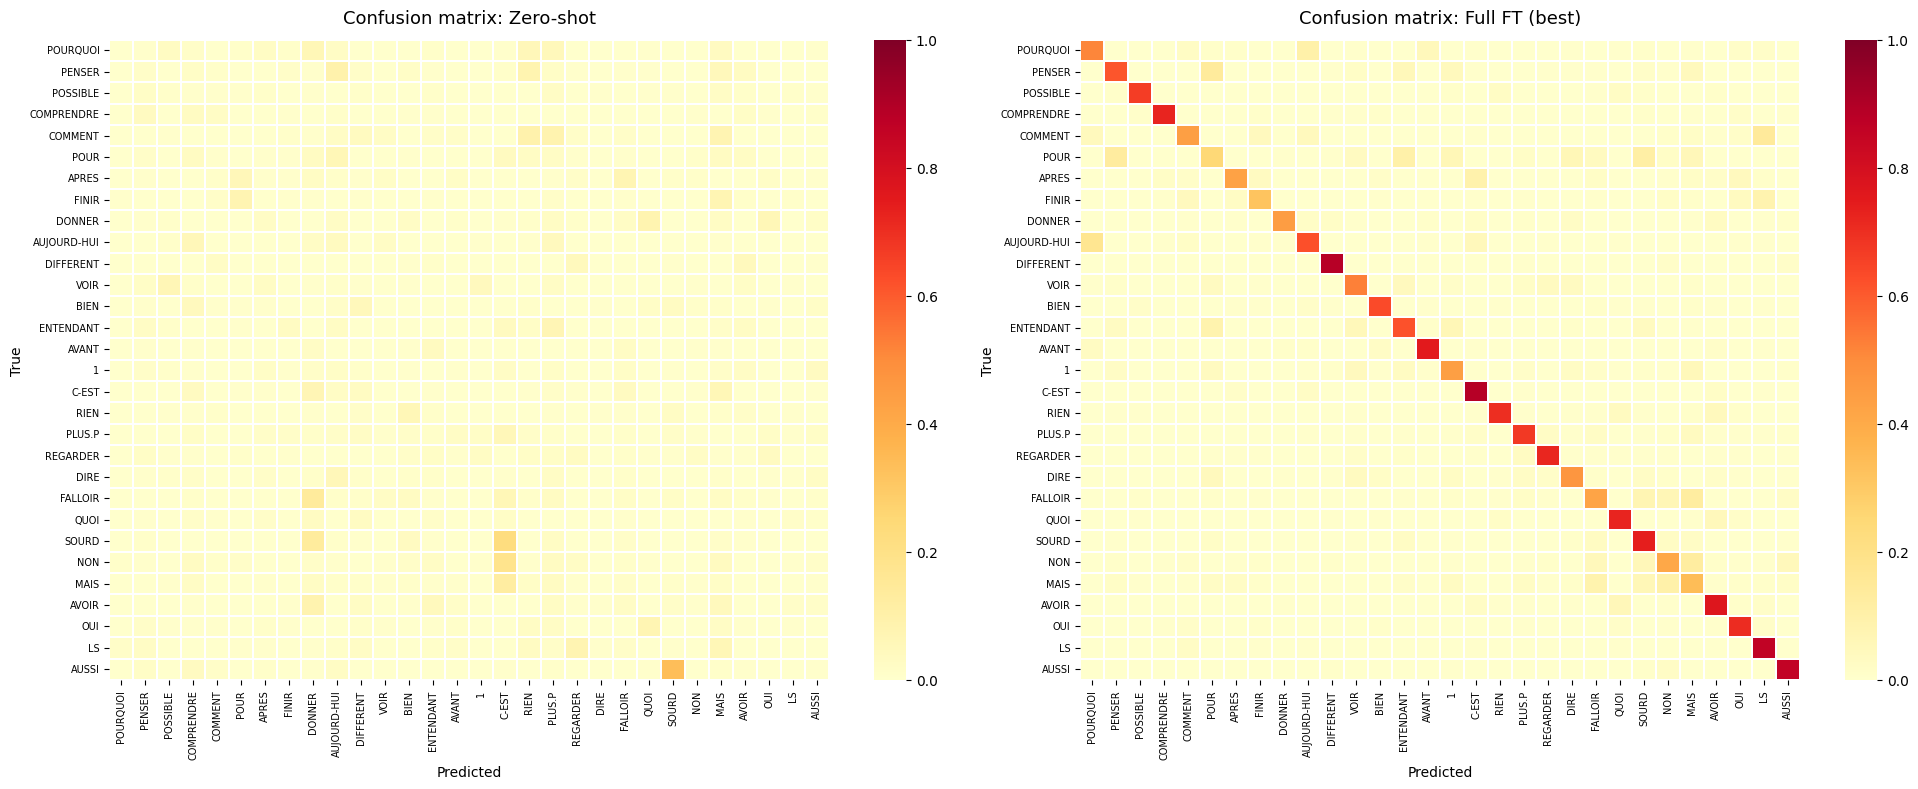

Saved.


In [37]:
class_names = [idx_to_class[i] for i in range(TOP_K)]
SHOW_N = 30

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, key, title in zip(
    axes,
    ['zero_shot', best_key],
    ['Zero-shot', results[best_key]['name'] + ' (best)']
):
    preds   = np.array(results[key]['preds'])
    labels  = np.array(results[key]['labels'])
    cm      = confusion_matrix(labels, preds, labels=list(range(TOP_K)))
    cm_norm = cm.astype(float) / (cm.sum(1, keepdims=True) + 1e-9)
    top_idx = np.argsort(cm.sum(1))[-SHOW_N:]
    cm_sub  = cm_norm[np.ix_(top_idx, top_idx)]
    ticks   = [class_names[i][:14] for i in top_idx]
    sns.heatmap(cm_sub, ax=ax, xticklabels=ticks, yticklabels=ticks,
                cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.3)
    ax.set_title('Confusion matrix: ' + title, fontsize=13, pad=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Cell 16 — Per-class accuracy

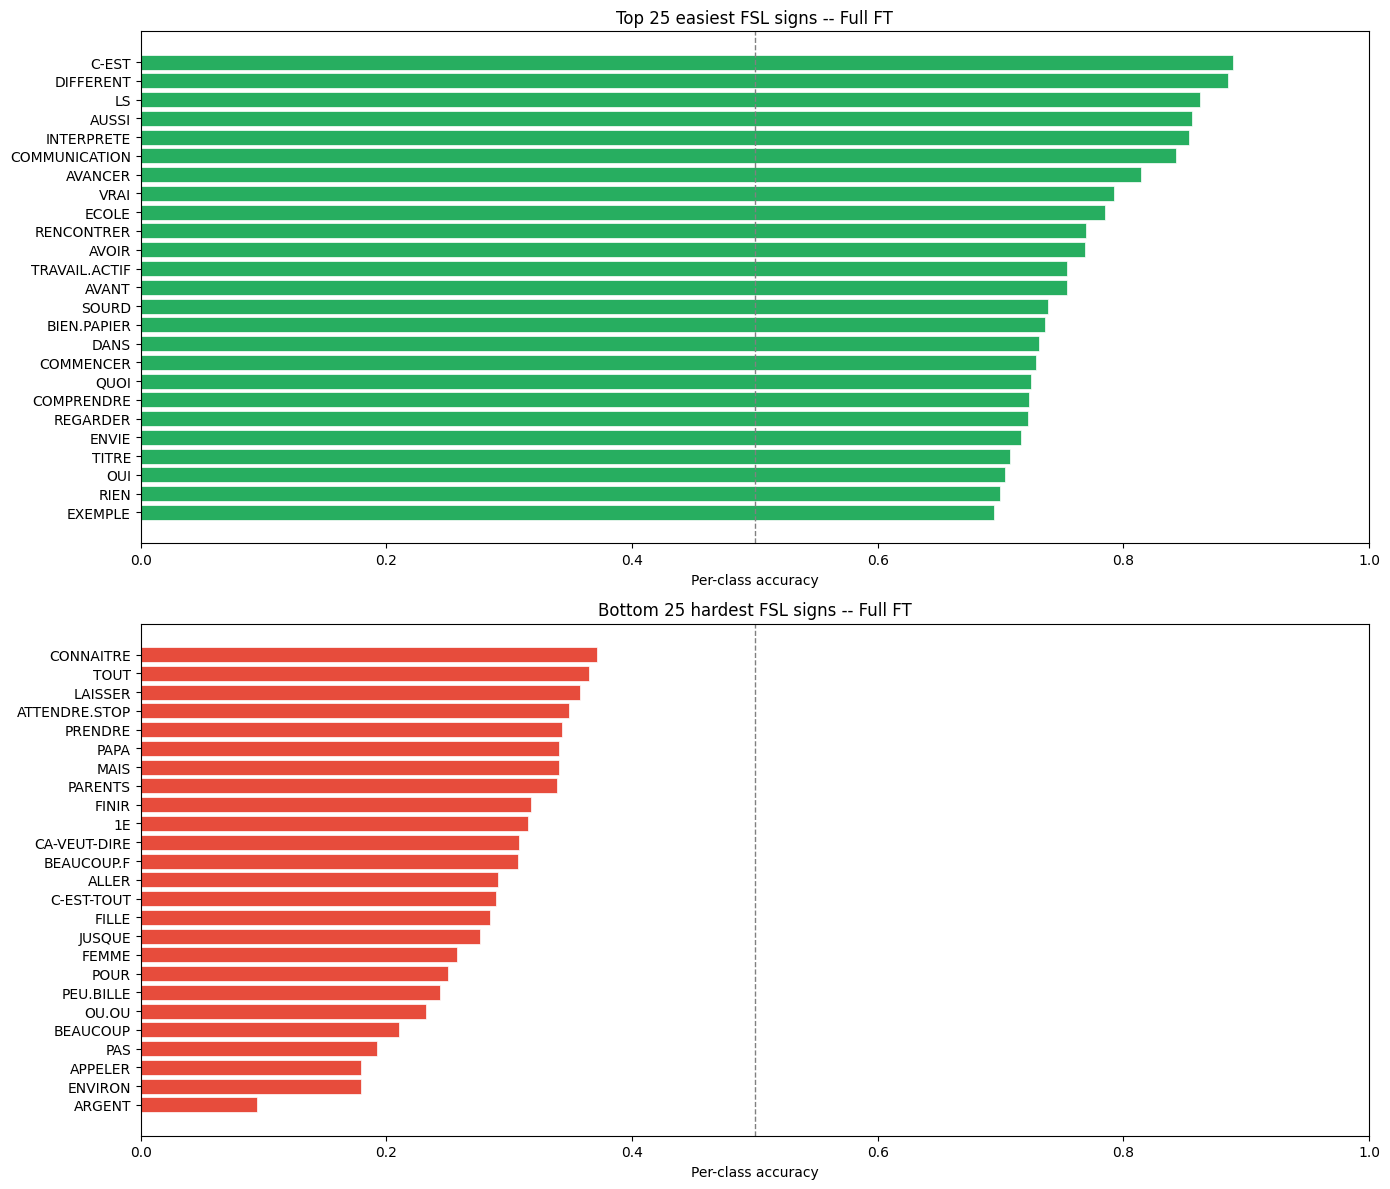

Saved.


In [38]:
preds  = np.array(results[best_key]['preds'])
labels = np.array(results[best_key]['labels'])

per_class  = {}
for i in range(TOP_K):
    mask = labels == i
    if mask.sum() > 0:
        per_class[class_names[i]] = float((preds[mask] == i).mean())

sorted_acc = sorted(per_class.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))
for ax, subset, title in zip(
    axes,
    [sorted_acc[:25], sorted_acc[-25:]],
    ['Top 25 easiest FSL signs', 'Bottom 25 hardest FSL signs']
):
    glosses = [x[0][:20] for x in subset]
    accs    = [x[1] for x in subset]
    colors  = ['#27ae60' if a >= 0.5 else '#e74c3c' for a in accs]
    ax.barh(glosses, accs, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Per-class accuracy')
    ax.set_title(title + ' -- ' + results[best_key]['name'], fontsize=12)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Cell 17 — Training curves

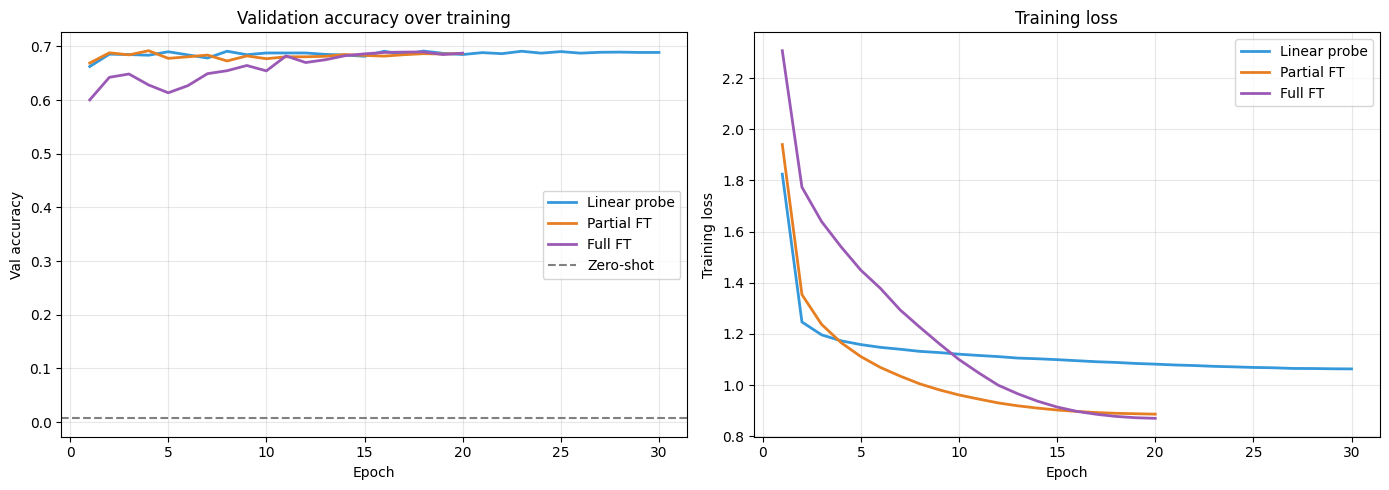

Saved.


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'linear_probe': '#3498db', 'partial_ft': '#e67e22', 'full_ft': '#9b59b6'}

for key, color in colors.items():
    if 'history' not in results[key] or not results[key]['history']:
        continue
    h = results[key]['history']
    ax1.plot([e['epoch'] for e in h], [e['val_acc']    for e in h], label=results[key]['name'], color=color, linewidth=2)
    ax2.plot([e['epoch'] for e in h], [e['train_loss'] for e in h], label=results[key]['name'], color=color, linewidth=2)

ax1.axhline(results['zero_shot']['test_acc'], color='gray', linestyle='--', linewidth=1.5, label='Zero-shot')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val accuracy')
ax1.set_title('Validation accuracy over training'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Training loss')
ax2.set_title('Training loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Cell 18 — Summary

In [39]:
print('='*52)
print('  EXPERIMENT COMPLETE')
print('='*52)
print('  ' + 'Strategy'.ljust(20) + 'Test Acc'.rjust(10))
print('  ' + '-'*32)
for key in order:
    r      = results[key]
    marker = '  <- best' if key == best_key else ''
    print('  ' + r['name'].ljust(20) + (str(round(r['test_acc']*100, 2)) + '%').rjust(10) + marker)

print('\nCheckpoints (survive re-runs):')
for f in sorted(os.listdir(CKPT_DIR)):
    size = os.path.getsize(CKPT_DIR + '/' + f)
    print('  ' + f.ljust(45) + str(round(size/1e6, 1)) + ' MB')

print('\nOutput plots:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(OUTPUT_DIR + '/' + f)
    print('  ' + f.ljust(45) + str(round(size/1024, 1)) + ' KB')

  EXPERIMENT COMPLETE
  Strategy              Test Acc
  --------------------------------
  Zero-shot                0.71%
  Linear probe            58.27%
  Partial FT              59.23%
  Full FT                  59.3%  <- best

Checkpoints (survive re-runs):
  Full_FT_best.pth                             13.5 MB
  Full_FT_meta.json                            0.0 MB
  Linear_probe_best.pth                        13.5 MB
  Linear_probe_meta.json                       0.0 MB
  Partial_FT_best.pth                          13.5 MB
  Partial_FT_meta.json                         0.0 MB
  asl_pose_transformer.pth                     17.1 MB
  zero_shot_result.json                        0.4 MB

Output plots:
  all_results.json                             1850.3 KB
  class_mapping.json                           3.8 KB
  confusion_matrices.png                       113.3 KB
  per_class_accuracy.png                       145.2 KB


In [41]:
import zipfile

ZIP_PATH = '/kaggle/working/experiment_results.zip'

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add all output files (plots, results json, class mapping)
    for f in os.listdir(OUTPUT_DIR):
        full_path = OUTPUT_DIR + '/' + f
        zipf.write(full_path, 'outputs/' + f)
        print('Added: outputs/' + f)

    # Add all checkpoints
    for f in os.listdir(CKPT_DIR):
        full_path = CKPT_DIR + '/' + f
        zipf.write(full_path, 'checkpoints/' + f)
        print('Added: checkpoints/' + f)

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print('Zip created: ' + ZIP_PATH)
print('Size: ' + str(round(size_mb, 1)) + ' MB')
print('Go to File -> Download to save it.')

Added: outputs/confusion_matrices.png
Added: outputs/all_results.json
Added: outputs/training_curves.png
Added: outputs/per_class_accuracy.png
Added: outputs/class_mapping.json
Added: checkpoints/Full_FT_best.pth
Added: checkpoints/Full_FT_meta.json
Added: checkpoints/Linear_probe_best.pth
Added: checkpoints/Partial_FT_best.pth
Added: checkpoints/zero_shot_result.json
Added: checkpoints/Partial_FT_meta.json
Added: checkpoints/Linear_probe_meta.json
Added: checkpoints/asl_pose_transformer.pth
Zip created: /kaggle/working/experiment_results.zip
Size: 53.9 MB
Go to File -> Download to save it.


In [42]:
import zipfile, os

DATASET_ZIP = '/kaggle/working/lsfb_isol_poses.zip'

print('Zipping LSFB-ISOL poses and metadata...')
print('This may take a few minutes...')

with zipfile.ZipFile(DATASET_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add instances.csv
    zipf.write(DATA_ROOT + '/instances.csv', 'lsfb_isol/instances.csv')
    print('Added: instances.csv')

    # Add metadata folder (splits, sign_occurrences, etc.)
    for root, dirs, files in os.walk(DATA_ROOT + '/metadata'):
        for f in files:
            full_path = os.path.join(root, f)
            rel_path  = full_path.replace(DATA_ROOT, 'lsfb_isol')
            zipf.write(full_path, rel_path)
            print('Added: ' + rel_path)

    # Add pose files
    pose_count = 0
    for root, dirs, files in os.walk(DATA_ROOT + '/poses'):
        for f in files:
            full_path = os.path.join(root, f)
            rel_path  = full_path.replace(DATA_ROOT, 'lsfb_isol')
            zipf.write(full_path, rel_path)
            pose_count += 1
            if pose_count % 10000 == 0:
                print('  Poses zipped so far: ' + str(pose_count))

size_gb = os.path.getsize(DATASET_ZIP) / 1e9
print('Done.')
print('File: ' + DATASET_ZIP)
print('Size: ' + str(round(size_gb, 2)) + ' GB')
print('Go to File -> Download to save it.')

Zipping LSFB-ISOL poses and metadata...
This may take a few minutes...
Added: instances.csv
Added: lsfb_isol/metadata/sign_occurrences.csv
Added: lsfb_isol/metadata/sign_to_index.csv
Added: lsfb_isol/metadata/splits/fold_3.json
Added: lsfb_isol/metadata/splits/fold_0.json
Added: lsfb_isol/metadata/splits/mini_sample.json
Added: lsfb_isol/metadata/splits/test.json
Added: lsfb_isol/metadata/splits/fold_4.json
Added: lsfb_isol/metadata/splits/train.json
Added: lsfb_isol/metadata/splits/fold_1.json
Added: lsfb_isol/metadata/splits/fold_2.json
Added: lsfb_isol/metadata/splits/all.json
  Poses zipped so far: 10000
  Poses zipped so far: 20000
  Poses zipped so far: 30000
  Poses zipped so far: 40000
  Poses zipped so far: 50000
  Poses zipped so far: 60000
  Poses zipped so far: 70000
  Poses zipped so far: 80000
  Poses zipped so far: 90000
  Poses zipped so far: 100000
  Poses zipped so far: 110000
  Poses zipped so far: 120000
  Poses zipped so far: 130000
  Poses zipped so far: 140000
  

In [43]:
import zipfile, os

ZIP_PATH    = '/kaggle/working/lsfb_isol_poses.zip'
CHUNK_SIZE  = 300 * 1024 * 1024   # 300 MB per chunk

with open(ZIP_PATH, 'rb') as f:
    chunk_num = 0
    while True:
        chunk = f.read(CHUNK_SIZE)
        if not chunk:
            break
        chunk_path = '/kaggle/working/lsfb_poses_part' + str(chunk_num) + '.bin'
        with open(chunk_path, 'wb') as out:
            out.write(chunk)
        size_mb = os.path.getsize(chunk_path) / 1e6
        print('Created: ' + chunk_path + '  (' + str(round(size_mb, 1)) + ' MB)')
        chunk_num += 1

print('Done. Download each part separately.')
print('To reassemble on your PC, run the cell below.')

Created: /kaggle/working/lsfb_poses_part0.bin  (314.6 MB)
Created: /kaggle/working/lsfb_poses_part1.bin  (314.6 MB)
Created: /kaggle/working/lsfb_poses_part2.bin  (314.6 MB)
Created: /kaggle/working/lsfb_poses_part3.bin  (190.5 MB)
Done. Download each part separately.
To reassemble on your PC, run the cell below.
